# Phase 1.8 — z=0 获取率的恒星质量依赖

仅运行 MC-tracer slow mode，计算 snapshot 98→99。按 snapshot 99 的 $8.5\leq\log_{10}(M_\star(<2R_{\star,1/2})/M_\odot)\leq11.5$、0.25 dex 分箱，每个 bin 最多选择 50 个中心星系。

In [1]:
# ---- Runtime settings ----
BASE_PATH = '/public/share/chenhouzun/TNG50-1/output/'
RANDOM_SEED = 42
TRACER_READ_BLOCK_SIZE = 2_000_000

# The reproducibility contract fixes tracer scans at 64 process workers.
COOLING_TABLE_DIR = 'data/external/cooling_tables'
DOWNLOAD_COOLING_TABLES_IF_MISSING = True
CACHE_DIR = 'data/interim/cache'
OUTPUT_DIR = 'data/processed'
FIGURE_DIR = 'results/figures'
REBUILD_SAMPLE = False  # False reuses valid sample, halo-state, and tracer-chunk caches
LOG_Y = False


In [2]:
# ---- Imports: use the packaged Phase 1.8 implementation ----
import sys
from pathlib import Path

# Resolve the project root whether Jupyter starts in the repository,
# in notebooks/, or in the historical Phase01 checkout location.
working_dir = Path.cwd().resolve()
candidate_roots = (
    working_dir,
    working_dir.parent,
    working_dir / 'project' / '1.8',
    working_dir / 'Phase01' / '1.8',
)
MODULE_DIR = next(
    (path for path in candidate_roots if (path / 'src' / 'analysis').is_dir()),
    None,
)
if MODULE_DIR is None:
    raise FileNotFoundError('Cannot locate the Phase 1.8 project root')
sys.path.insert(0, str(MODULE_DIR.resolve()))
import matplotlib.pyplot as plt

from src.utils.config import Phase18Config
from src.physics.cooling_function import (
    LGAL_TABLE_FILENAMES,
    LgalCoolingFunction,
    download_lgal_cooling_tables,
)
from src.analysis.pipeline import run_phase18
from src.io.results import save_phase18_result
from src.plotting import (
    plot_normalized_mass_dependence,
    plot_reheating_comparison,
    plot_tracer_history_heatmaps,
)

COOLING_TABLE_DIR = MODULE_DIR / COOLING_TABLE_DIR
CACHE_DIR = MODULE_DIR / CACHE_DIR
OUTPUT_DIR = MODULE_DIR / OUTPUT_DIR
FIGURE_DIR = MODULE_DIR / FIGURE_DIR
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


## 1. 配置与冷却函数

In [3]:
config = Phase18Config(
    base_path=BASE_PATH,
    random_seed=RANDOM_SEED,
    tracer_read_block_size=TRACER_READ_BLOCK_SIZE,
)
print('stellar-mass-bin edges:', config.mass_bin_edges)
print('sample limit per bin:', config.sample_per_bin)
print('tracer scan:', config.tracer_workers, config.tracer_parallel_backend)

cooling_dir = Path(COOLING_TABLE_DIR)
missing_tables = [
    name for name in LGAL_TABLE_FILENAMES
    if not (cooling_dir / name).is_file()
]
if missing_tables and DOWNLOAD_COOLING_TABLES_IF_MISSING:
    download_lgal_cooling_tables(cooling_dir)
cooling_function = LgalCoolingFunction.from_directory(cooling_dir)
print('cooling tables:', cooling_function.source_directory)


stellar-mass-bin edges: [ 8.5   8.75  9.    9.25  9.5   9.75 10.   10.25 10.5  10.75 11.   11.25
 11.5 ]
sample limit per bin: 50
tracer scan: 64 process
cooling tables: /public/home/zju_visitor/LiuYuanhao/CGM_project/scripts/sh/1.8/cooling_tables


## 2. 运行 slow mode

重新执行此 cell 时会校验并跳过已有缓存。程序会扫描 ParentID→TracerID、TracerID→另一端 ParentID，以及所需 gas/star/wind/BH parent 的物态；所有 chunk 均支持断点续扫。

In [4]:
result = run_phase18(
    cooling_function,
    config=config,
    cache_dir=CACHE_DIR,
    rebuild_sample=REBUILD_SAMPLE,
    verbose=True,
)

[sample bin 8.50,8.75] 1/50 sub=704869
[sample bin 8.50,8.75] 2/50 sub=711648
[sample bin 8.50,8.75] 3/50 sub=756479
[sample bin 8.50,8.75] 4/50 sub=730773
[sample bin 8.50,8.75] 5/50 sub=817961
[sample bin 8.50,8.75] 6/50 sub=776708
[sample bin 8.50,8.75] 7/50 sub=823520
[sample bin 8.50,8.75] 8/50 sub=783833
[sample bin 8.50,8.75] 9/50 sub=755146
[sample bin 8.50,8.75] 10/50 sub=855177
[sample bin 8.50,8.75] 11/50 sub=778758
[sample bin 8.50,8.75] 12/50 sub=752860
[sample bin 8.50,8.75] 13/50 sub=741473
[sample bin 8.50,8.75] 14/50 sub=736072
[sample bin 8.50,8.75] 15/50 sub=749803
[sample bin 8.50,8.75] 16/50 sub=746108
[sample bin 8.50,8.75] 17/50 sub=713481
[sample bin 8.50,8.75] 18/50 sub=724509
[sample bin 8.50,8.75] 19/50 sub=751381
[sample bin 8.50,8.75] 20/50 sub=777693
[sample bin 8.50,8.75] 21/50 sub=676908
[sample bin 8.50,8.75] 22/50 sub=773721
[sample bin 8.50,8.75] 23/50 sub=783231
[sample bin 8.50,8.75] 24/50 sub=733120
[sample bin 8.50,8.75] 25/50 sub=770196
[sample b

/public/home/zju_visitor/LiuYuanhao/CGM_project/scripts/sh/1.8/sampling.py:194: RuntimeWarning: Mass bin [11.25, 11.50) has only 13 candidate galaxies (<15); selecting all.
  warnings.warn(message, RuntimeWarning)


[sample bin 11.25,11.50] 1/13 sub=264883
[sample bin 11.25,11.50] 2/13 sub=338446
[sample bin 11.25,11.50] 3/13 sub=348901
[sample bin 11.25,11.50] 4/13 sub=371126
[sample bin 11.25,11.50] 5/13 sub=352426
[sample bin 11.25,11.50] 6/13 sub=368843
[sample bin 11.25,11.50] 7/13 sub=345872
[sample bin 11.25,11.50] 8/13 sub=360923
[sample bin 11.25,11.50] 9/13 sub=242788
[sample bin 11.25,11.50] 10/13 sub=333424
[sample bin 11.25,11.50] 11/13 sub=324123
[sample bin 11.25,11.50] 12/13 sub=390932
[sample bin 11.25,11.50] 13/13 sub=143880
[WARNING] Mass bin [11.25, 11.50) has only 13 valid snap98->99 MPB galaxies after validation (<15).


/public/home/zju_visitor/LiuYuanhao/CGM_project/scripts/sh/1.8/sampling.py:308: RuntimeWarning: Mass bin [11.25, 11.50) has only 13 valid snap98->99 MPB galaxies after validation (<15).
  warnings.warn(message, RuntimeWarning)


[membership] valid=542, rejected=0
[state] cache check complete: cached=0, pending=542, total=542
[state] computed 1/542
[state] computed 2/542
[state] computed 3/542
[state] computed 4/542
[state] computed 5/542
[state] computed 6/542
[state] computed 7/542
[state] computed 8/542
[state] computed 9/542
[state] computed 10/542
[state] computed 11/542
[state] computed 12/542
[state] computed 13/542
[state] computed 14/542
[state] computed 15/542
[state] computed 16/542
[state] computed 17/542
[state] computed 18/542
[state] computed 19/542
[state] computed 20/542
[state] computed 21/542
[state] computed 22/542
[state] computed 23/542
[state] computed 24/542
[state] computed 25/542
[state] computed 26/542
[state] computed 27/542
[state] computed 28/542
[state] computed 29/542
[state] computed 30/542
[state] computed 31/542
[state] computed 32/542
[state] computed 33/542
[state] computed 34/542
[state] computed 35/542
[state] computed 36/542
[state] computed 37/542
[state] computed 38/542

## 3. 检查每个质量 bin 的候选数与最终样本数

候选数或通过 MPB 校验后的样本数少于 15 时，采样阶段也会直接输出 `[WARNING]`。

In [10]:
metadata = result['metadata']
sample_meta = metadata['sample_metadata']
stats = result['binned_statistics']
print('selected halos:', metadata['selected_halo_count'])
print('dt:', metadata['dt_gyr'], 'Gyr')
print(f"{'mass bin':>13s} {'candidates':>10s} {'selected':>9s} {'valid states':>12s}")
for i in range(len(stats['mass_bin_center'])):
    print(
        f"[{stats['mass_bin_low'][i]:.2f},{stats['mass_bin_high'][i]:.2f}) "
        f"{sample_meta['candidate_counts'][i]:10d} "
        f"{sample_meta['selected_counts'][i]:9d} "
        f"{stats['n_halos'][i]:12d}"
    )


selected halos: 542
dt: 0.13648835460409003 Gyr
     mass bin candidates  selected valid states
[8.50,8.75)        611        50           50
[8.75,9.00)        523        50           50
[9.00,9.25)        391        50           50
[9.25,9.50)        328        50           50
[9.50,9.75)        222        50           50
[9.75,10.00)        175        50           50
[10.00,10.25)        166        50           50
[10.25,10.50)        121        50           50
[10.50,10.75)         84        50           50
[10.75,11.00)         69        50           50
[11.00,11.25)         30        29           29
[11.25,11.50)         13        13           13


## 4. 保存逐晕结果及原始/归一化分箱统计

In [6]:
prefix = OUTPUT_DIR / 'phase18_slow_mstar8p5-11p5_snap098_099'
saved = save_phase18_result(result, prefix)
for name, path in saved.items():
    print(f'{name}: {path}')


json: /public/home/zju_visitor/LiuYuanhao/CGM_project/scripts/sh/1.8/output/phase18_slow_mstar8p5-11p5_snap098_099.json
halos_npz: /public/home/zju_visitor/LiuYuanhao/CGM_project/scripts/sh/1.8/output/phase18_slow_mstar8p5-11p5_snap098_099_halos.npz
halos_csv: /public/home/zju_visitor/LiuYuanhao/CGM_project/scripts/sh/1.8/output/phase18_slow_mstar8p5-11p5_snap098_099_halos.csv
binned_npz: /public/home/zju_visitor/LiuYuanhao/CGM_project/scripts/sh/1.8/output/phase18_slow_mstar8p5-11p5_snap098_099_binned.npz
tracer_history_npz: /public/home/zju_visitor/LiuYuanhao/CGM_project/scripts/sh/1.8/output/phase18_slow_mstar8p5-11p5_snap098_099_tracer_history.npz
normalized_m200c_npz: /public/home/zju_visitor/LiuYuanhao/CGM_project/scripts/sh/1.8/output/phase18_slow_mstar8p5-11p5_snap098_099_normalized_m200c.npz
normalized_mhot_npz: /public/home/zju_visitor/LiuYuanhao/CGM_project/scripts/sh/1.8/output/phase18_slow_mstar8p5-11p5_snap098_099_normalized_mhot.npz
normalized_mcgm_npz: /public/home/zju_

## 5. 四幅归一化质量依赖图

每幅图都包含五种 rate，其中 `L-GALAXIES (SN)` 为扣除 S1.7 reheating 后截断于零的有效冷却率；阴影为 16th–84th percentile。四种归一化质量均取 snapshot 98/99 端点均值。

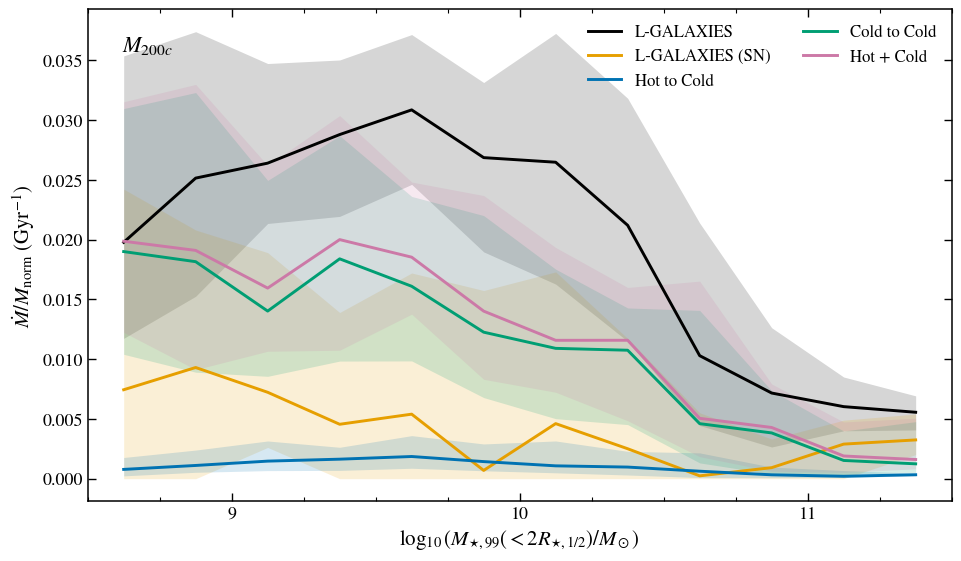

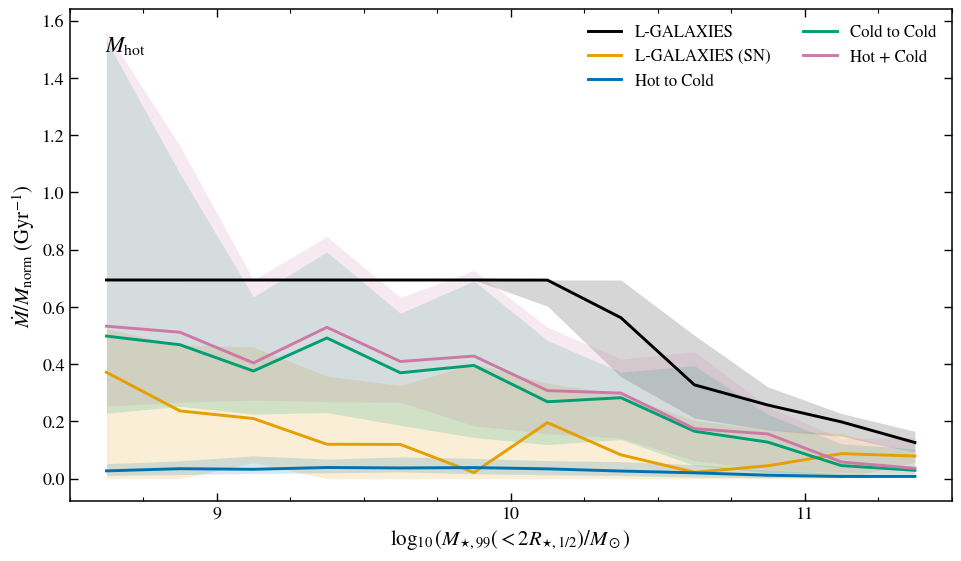

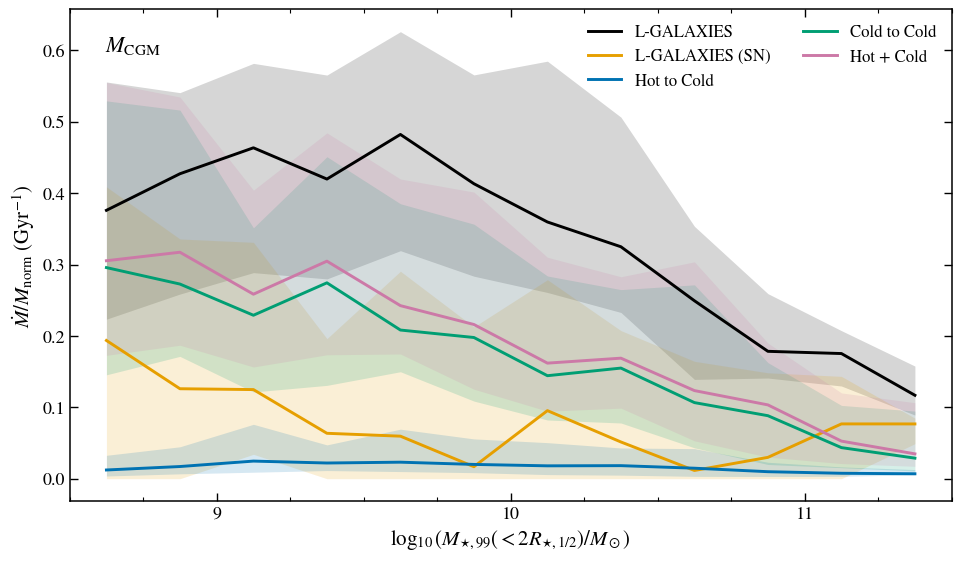

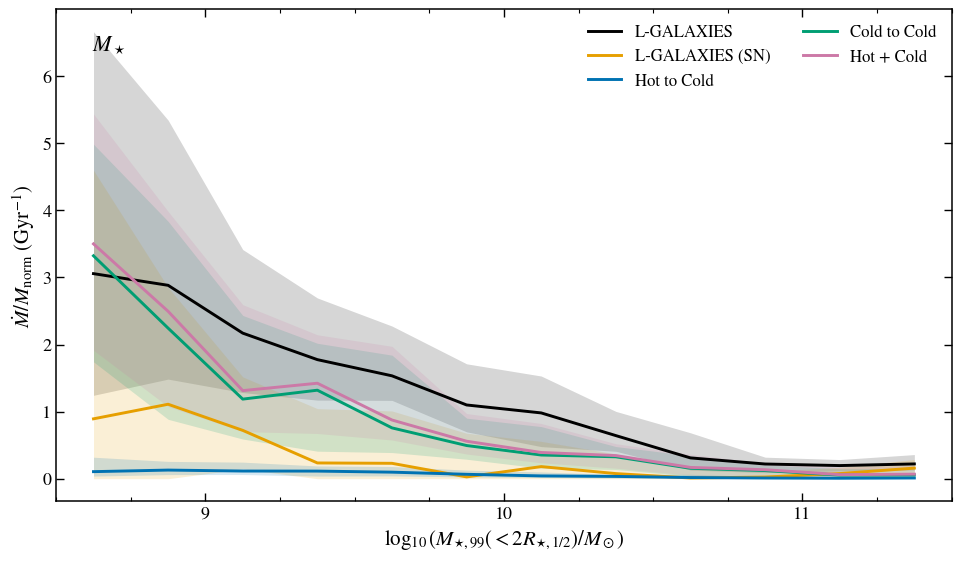

In [7]:
normalized = result['normalized_statistics']
for normalization in ('m200c', 'mhot', 'mcgm', 'mstar'):
    fig = plot_normalized_mass_dependence(
        normalized[normalization],
        normalization=normalization,
        log_y=LOG_Y,
        save_path=FIGURE_DIR / f'phase18_mass_dependence_normalized_{normalization}',
    )
    plt.show()


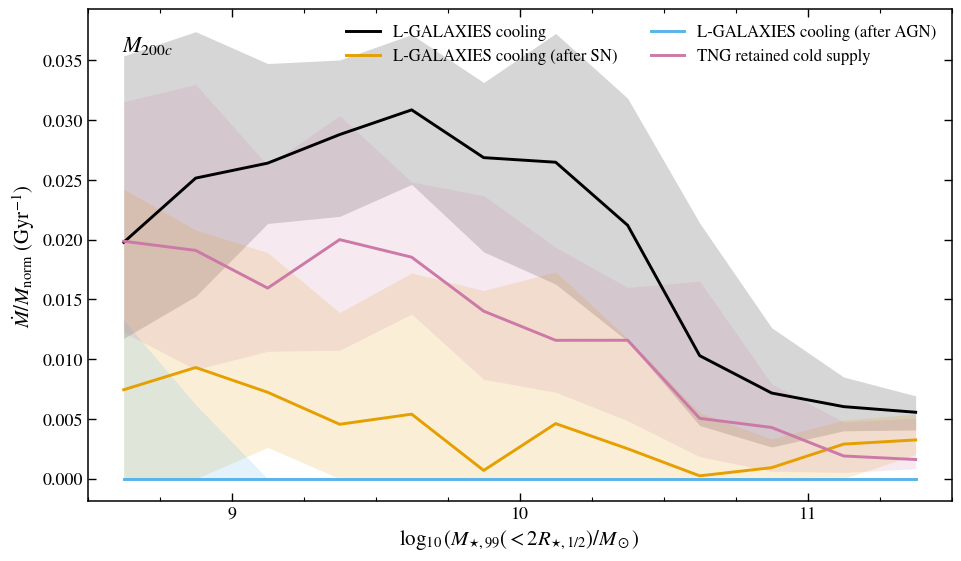

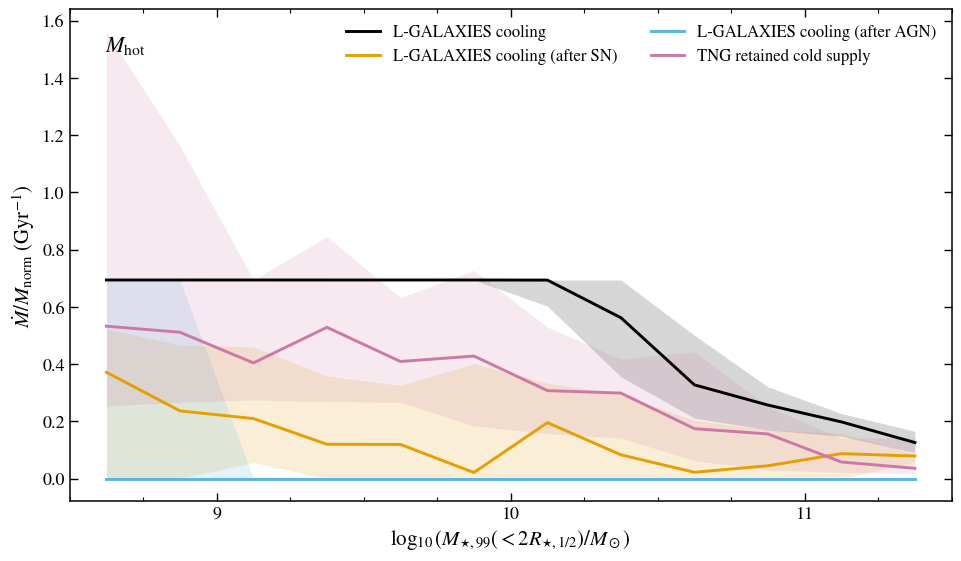

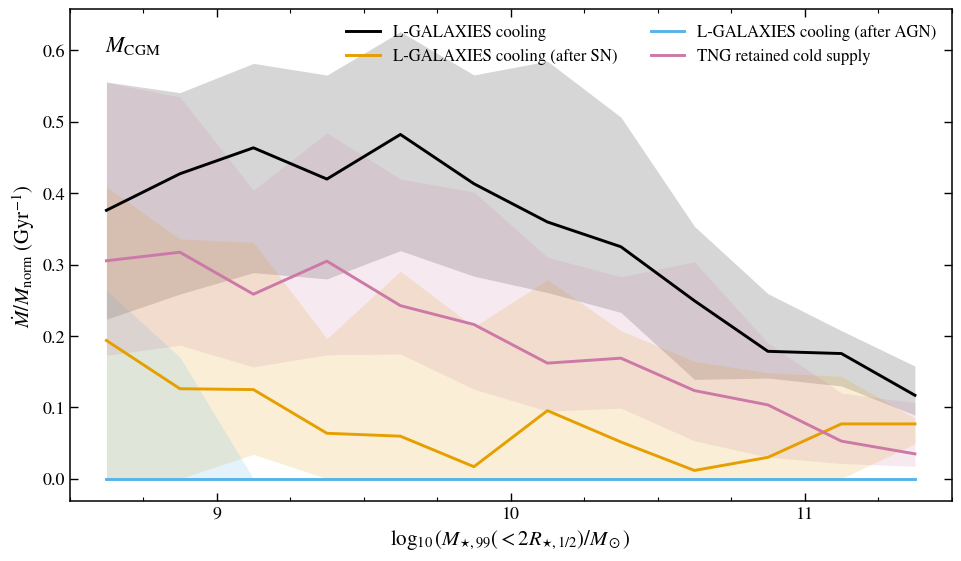

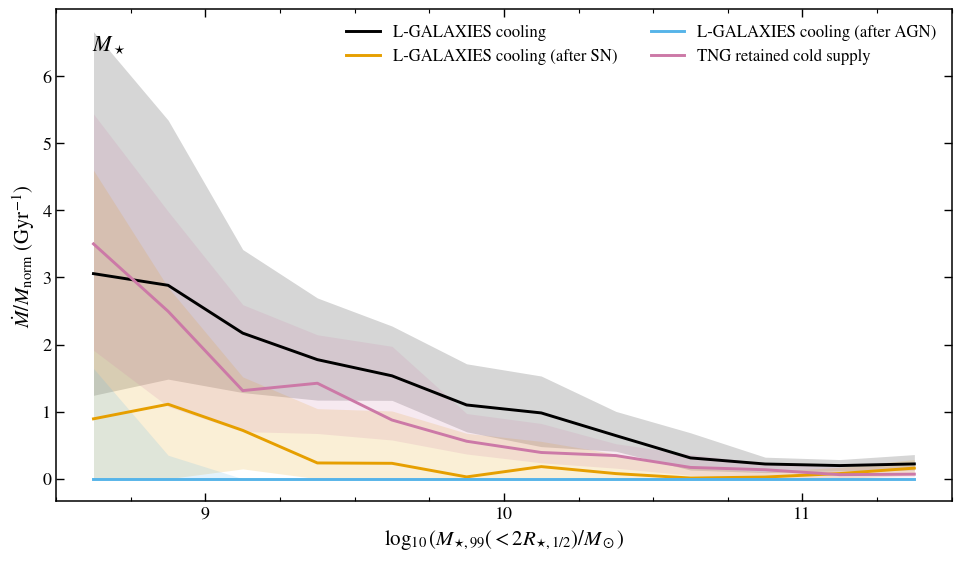

BH-free endpoints: 35 / 542 (snap 98); 33 / 542 (snap 99)
AGN-clipped endpoints: 507 (snap 98); 509 (snap 99)


In [13]:
import numpy as np

from src.analysis.supply_diagnostics import (
    NORMALIZATION_MASS_FIELDS,
    add_agn_percentiles,
)
from src.io.catalog import load_selected_subhalo_bh_mass
from src.physics.feedback import apply_henriques_radio_mode
from src.plotting import (
    NORMALIZATION_STYLES,
    _plot_selected_mass_dependence,
)

halos = result['halo_results']
m_bh_prev = load_selected_subhalo_bh_mass(
    BASE_PATH,
    config.snap_prev,
    halos['subfind_id_prev'],
    h=config.h,
)
m_bh_cur = load_selected_subhalo_bh_mass(
    BASE_PATH,
    config.snap_cur,
    halos['subfind_id_cur'],
    h=config.h,
)
rate_agn_prev, suppression_agn_prev = apply_henriques_radio_mode(
    halos['rate_sam_snap98_msun_per_yr'],
    halos['m_hot_prev_msun'],
    m_bh_prev,
    halos['v200c_km_s_prev'],
)
rate_agn_cur, suppression_agn_cur = apply_henriques_radio_mode(
    halos['rate_sam_snap99_msun_per_yr'],
    halos['m_hot_cur_msun'],
    m_bh_cur,
    halos['v200c_km_s_cur'],
)
# Match the baseline contract: evaluate each endpoint, then average.
rate_sam_agn_msun_per_yr = 0.5 * (rate_agn_prev + rate_agn_cur)
normalization_labels = {
    name: label for name, label, _ in NORMALIZATION_STYLES
}
plot_series = (
    ('sam', 'L-GALAXIES cooling', '#000000'),
    ('sam_sn', 'L-GALAXIES cooling (after SN)', '#E69F00'),
    ('sam_agn', 'L-GALAXIES cooling (after AGN)', '#56B4E9'),
    ('cooling_plus_inflow', 'TNG retained cold supply', '#CC79A7'),
)

for normalization, mass_field in NORMALIZATION_MASS_FIELDS.items():
    masses = np.asarray(halos[mass_field], dtype=float)
    agn_normalized = np.full(masses.shape, np.nan, dtype=float)
    valid = (
        np.isfinite(rate_sam_agn_msun_per_yr)
        & np.isfinite(masses)
        & (masses > 0)
    )
    agn_normalized[valid] = (
        rate_sam_agn_msun_per_yr[valid] / masses[valid] * 1.0e9
    )
    statistics = add_agn_percentiles(
        result['normalized_statistics'][normalization],
        agn_normalized,
        halos['mass_bin_index'],
    )
    fig = _plot_selected_mass_dependence(
        statistics,
        mode='slow',
        series=plot_series,
        annotation_label=normalization_labels[normalization],
        y_label=r'$\dot{M}/M_{\rm norm}\ ({\rm Gyr}^{-1})$',
        log_y=LOG_Y,
        save_path=(
            FIGURE_DIR
            / f'phase18_mass_dependence_normalized_{normalization}'
        ),
    )
    plt.show()

print(
    'BH-free endpoints:',
    int(np.count_nonzero(m_bh_prev == 0)), '/', len(m_bh_prev), '(snap 98);',
    int(np.count_nonzero(m_bh_cur == 0)), '/', len(m_bh_cur), '(snap 99)',
)
print(
    'AGN-clipped endpoints:',
    int(np.count_nonzero(
        (rate_agn_prev == 0)
        & (halos['rate_sam_snap98_msun_per_yr'] > 0)
    )),
    '(snap 98);',
    int(np.count_nonzero(
        (rate_agn_cur == 0)
        & (halos['rate_sam_snap99_msun_per_yr'] > 0)
    )),
    '(snap 99)',
)


# Integrated inward-delivery extension

The following section reuses the same configuration, physics, sample, cache, I/O, analysis, and plotting modules. Only the additional inner-hot tracer channels and their historical output schema differ.


# Phase 1.8.1 — z=0 冷气体供给与中心气体输运

这是 1.8 的隔离分支。保留原始 L-GALAXIES 冷却率和 tracer 的 `Hot + Cold`，并逐星系加入 `Outer hot/cold → Inner hot`，构造 `TNG total inward delivery`；不计算 `L-GALAXIES (SN)`。

In [1]:
# ---- Runtime settings ----
BASE_PATH = '/public/share/chenhouzun/TNG50-1/output/'
RANDOM_SEED = 42
TRACER_READ_BLOCK_SIZE = 2_000_000

# The reproducibility contract fixes tracer scans at 64 process workers.
# Reuse shared cooling tables and caches; preserve the phase181 prefix.
COOLING_TABLE_DIR = 'data/external/cooling_tables'
DOWNLOAD_COOLING_TABLES_IF_MISSING = False
CACHE_DIR = 'data/interim/cache'
OUTPUT_DIR = 'data/processed'
FIGURE_DIR = 'results/figures'
REBUILD_SAMPLE = False  # False reuses valid sample, halo-state, and tracer-chunk caches
LOG_Y = False


In [2]:
# ---- Imports: use the integrated inward-delivery workflow ----
import sys
from pathlib import Path

# Resolve the project root independently of Jupyter's launch directory.
working_dir = Path.cwd().resolve()
candidate_roots = (
    working_dir,
    working_dir.parent,
    working_dir / 'project' / '1.8',
    working_dir / 'Phase01' / '1.8',
)
MODULE_DIR = next(
    (path for path in candidate_roots if (path / 'src' / 'analysis').is_dir()),
    None,
)
if MODULE_DIR is None:
    raise FileNotFoundError('Cannot locate the Phase 1.8 project root')
sys.path.insert(0, str(MODULE_DIR.resolve()))
import matplotlib.pyplot as plt
import numpy as np

from src.utils.config import Phase18Config
from src.physics.cooling_function import (
    LGAL_TABLE_FILENAMES,
    LgalCoolingFunction,
    download_lgal_cooling_tables,
)
from src.analysis.inward_delivery_pipeline import run_phase18
from src.io.results import save_phase18_result
from src.plotting import (
    plot_inner_hot_delivery_components,
    plot_normalized_mass_dependence,
    plot_tracer_history_heatmaps,
)

COOLING_TABLE_DIR = MODULE_DIR / COOLING_TABLE_DIR
CACHE_DIR = MODULE_DIR / CACHE_DIR
OUTPUT_DIR = MODULE_DIR / OUTPUT_DIR
FIGURE_DIR = MODULE_DIR / FIGURE_DIR
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


## 1. 配置与冷却函数

In [3]:
config = Phase18Config(
    base_path=BASE_PATH,
    random_seed=RANDOM_SEED,
    tracer_read_block_size=TRACER_READ_BLOCK_SIZE,
)
print('stellar-mass-bin edges:', config.mass_bin_edges)
print('sample limit per bin:', config.sample_per_bin)
print('tracer scan:', config.tracer_workers, config.tracer_parallel_backend)

cooling_dir = Path(COOLING_TABLE_DIR)
missing_tables = [
    name for name in LGAL_TABLE_FILENAMES
    if not (cooling_dir / name).is_file()
]
if missing_tables and DOWNLOAD_COOLING_TABLES_IF_MISSING:
    download_lgal_cooling_tables(cooling_dir)
cooling_function = LgalCoolingFunction.from_directory(cooling_dir)
print('cooling tables:', cooling_function.source_directory)


stellar-mass-bin edges: [ 8.5   8.75  9.    9.25  9.5   9.75 10.   10.25 10.5  10.75 11.   11.25
 11.5 ]
sample limit per bin: 50
tracer scan: 64 process
cooling tables: /public/home/zju_visitor/LiuYuanhao/CGM_project/scripts/sh/1.8/cooling_tables


## 2. 运行 slow mode

程序复用父目录 1.8 的 sample、halo state 和已有 tracer 缓存，不会执行 S1.7 reheating 修正。新定义只额外查询一次 snap 99 中外部源 tracer 的 ParentID，并单独缓存这次查询。

In [4]:
result = run_phase18(
    cooling_function,
    config=config,
    cache_dir=CACHE_DIR,
    rebuild_sample=REBUILD_SAMPLE,
    verbose=True,
)


loading sample cache: /public/home/zju_visitor/LiuYuanhao/CGM_project/scripts/sh/1.8/1.8.1/../output/cache/samples/sample_v4_mstar2rh_path197fbdc5_s42_m8p50-11p50_d0p25_n50_snap098-099
[membership] valid=542, rejected=0
[state] cached 1/542 sub=704869
[state] cached 2/542 sub=711648
[state] cached 3/542 sub=756479
[state] cached 4/542 sub=730773
[state] cached 5/542 sub=817961
[state] cached 6/542 sub=776708
[state] cached 7/542 sub=823520
[state] cached 8/542 sub=783833
[state] cached 9/542 sub=755146
[state] cached 10/542 sub=855177
[state] cached 11/542 sub=778758
[state] cached 12/542 sub=752860
[state] cached 13/542 sub=741473
[state] cached 14/542 sub=736072
[state] cached 15/542 sub=749803
[state] cached 16/542 sub=746108
[state] cached 17/542 sub=713481
[state] cached 18/542 sub=724509
[state] cached 19/542 sub=751381
[state] cached 20/542 sub=777693
[state] cached 21/542 sub=676908
[state] cached 22/542 sub=773721
[state] cached 23/542 sub=783231
[state] cached 24/542 sub=7331

## 3. 检查每个质量 bin 的候选数与最终样本数

候选数或通过 MPB 校验后的样本数少于 15 时，采样阶段也会直接输出 `[WARNING]`。

In [5]:
metadata = result['metadata']
sample_meta = metadata['sample_metadata']
stats = result['binned_statistics']
print('selected halos:', metadata['selected_halo_count'])
print('dt:', metadata['dt_gyr'], 'Gyr')
print(f"{'mass bin':>13s} {'candidates':>10s} {'selected':>9s} {'valid states':>12s}")
for i in range(len(stats['mass_bin_center'])):
    print(
        f"[{stats['mass_bin_low'][i]:.2f},{stats['mass_bin_high'][i]:.2f}) "
        f"{sample_meta['candidate_counts'][i]:10d} "
        f"{sample_meta['selected_counts'][i]:9d} "
        f"{stats['n_halos'][i]:12d}"
    )


selected halos: 542
dt: 0.13648835460409003 Gyr
     mass bin candidates  selected valid states
[8.50,8.75)        611        50           50
[8.75,9.00)        523        50           50
[9.00,9.25)        391        50           50
[9.25,9.50)        328        50           50
[9.50,9.75)        222        50           50
[9.75,10.00)        175        50           50
[10.00,10.25)        166        50           50
[10.25,10.50)        121        50           50
[10.50,10.75)         84        50           50
[10.75,11.00)         69        50           50
[11.00,11.25)         30        29           29
[11.25,11.50)         13        13           13


## 4. 保存逐晕结果及原始/归一化分箱统计

In [6]:
prefix = OUTPUT_DIR / 'phase181_slow_mstar8p5-11p5_snap098_099'
saved = save_phase18_result(result, prefix)
for name, path in saved.items():
    print(f'{name}: {path}')


json: /public/home/zju_visitor/LiuYuanhao/CGM_project/scripts/sh/1.8/1.8.1/output/phase181_slow_mstar8p5-11p5_snap098_099.json
halos_npz: /public/home/zju_visitor/LiuYuanhao/CGM_project/scripts/sh/1.8/1.8.1/output/phase181_slow_mstar8p5-11p5_snap098_099_halos.npz
halos_csv: /public/home/zju_visitor/LiuYuanhao/CGM_project/scripts/sh/1.8/1.8.1/output/phase181_slow_mstar8p5-11p5_snap098_099_halos.csv
binned_npz: /public/home/zju_visitor/LiuYuanhao/CGM_project/scripts/sh/1.8/1.8.1/output/phase181_slow_mstar8p5-11p5_snap098_099_binned.npz
tracer_history_npz: /public/home/zju_visitor/LiuYuanhao/CGM_project/scripts/sh/1.8/1.8.1/output/phase181_slow_mstar8p5-11p5_snap098_099_tracer_history.npz
normalized_m200c_npz: /public/home/zju_visitor/LiuYuanhao/CGM_project/scripts/sh/1.8/1.8.1/output/phase181_slow_mstar8p5-11p5_snap098_099_normalized_m200c.npz
normalized_mhot_npz: /public/home/zju_visitor/LiuYuanhao/CGM_project/scripts/sh/1.8/1.8.1/output/phase181_slow_mstar8p5-11p5_snap098_099_normalize

## 5. 四幅归一化质量依赖图

每幅图仅显示 `L-GALAXIES`、`Hot + Cold` 和 `TNG total inward delivery`。后者逐星系定义为 `Hot + Cold + Outer hot → Inner hot + Outer cold → Inner hot`，表示不区分最终冷热相态的中心向内输运；阴影为 16th–84th percentile。

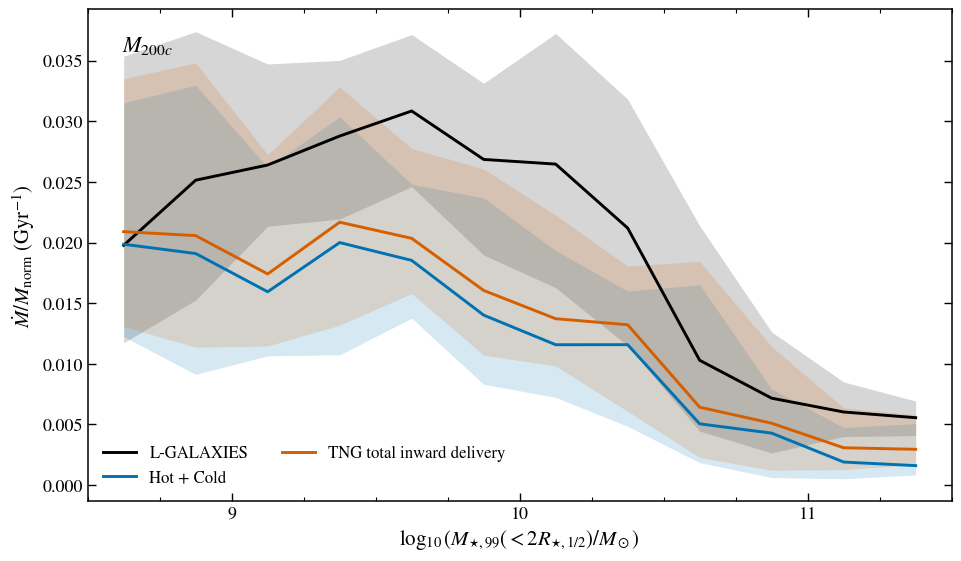

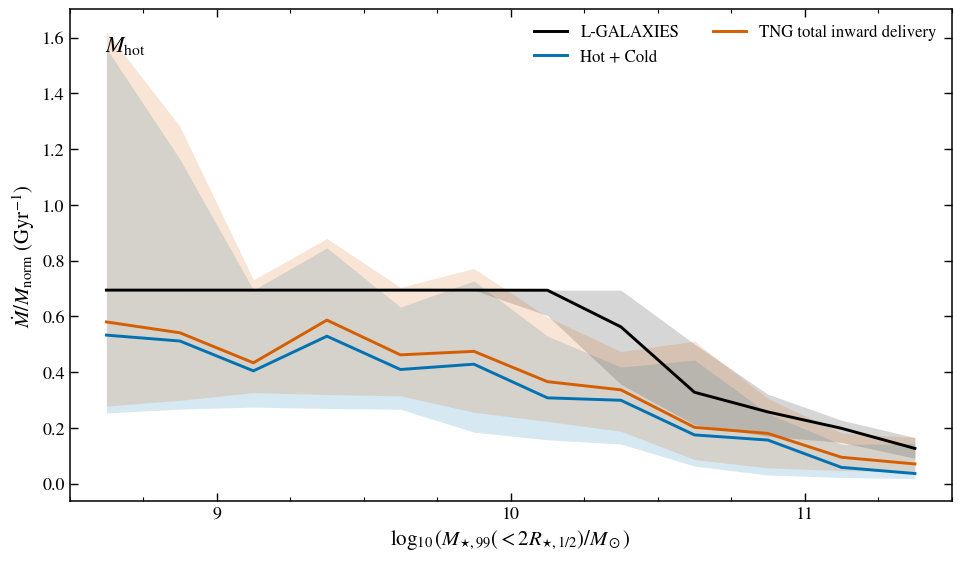

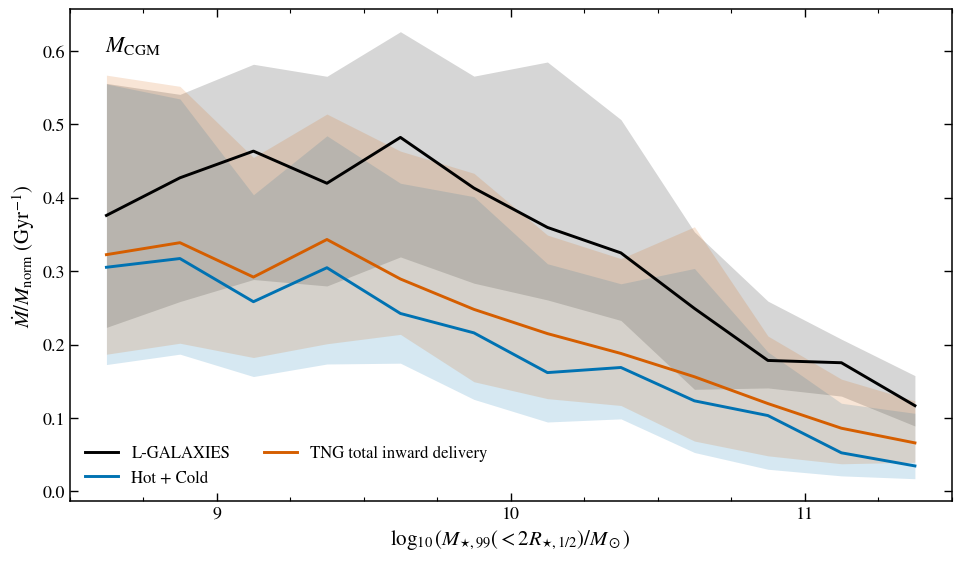

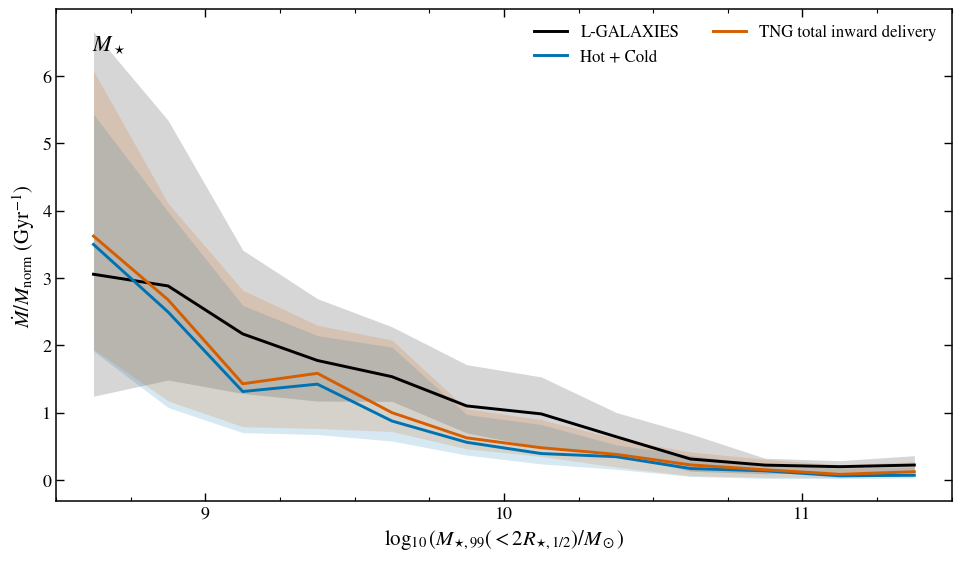

In [10]:
normalized = result['normalized_statistics']
for normalization in ('m200c', 'mhot', 'mcgm', 'mstar'):
    fig = plot_normalized_mass_dependence(
        normalized[normalization],
        normalization=normalization,
        log_y=LOG_Y,
        save_path=FIGURE_DIR / f'phase181_mass_dependence_normalized_{normalization}',
    )
    plt.show()


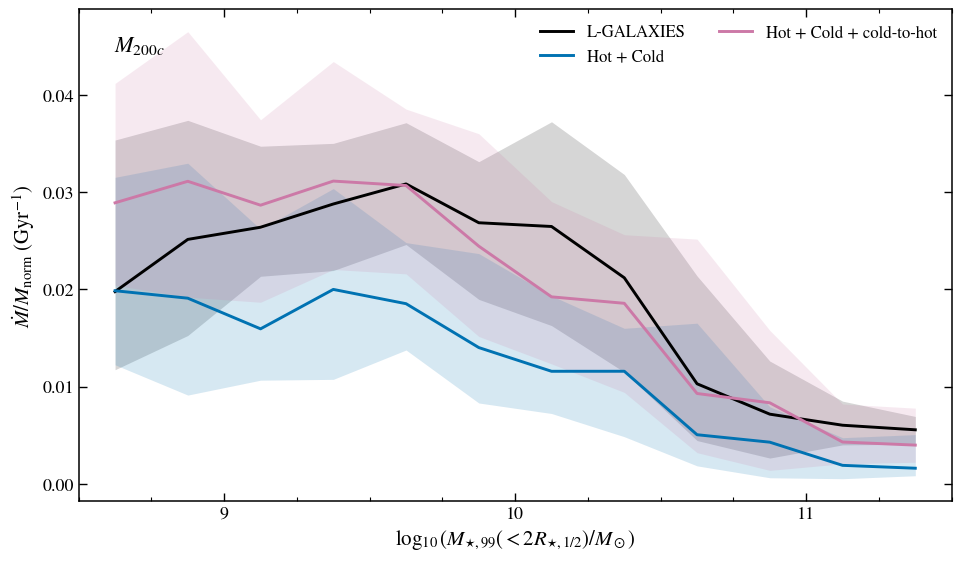

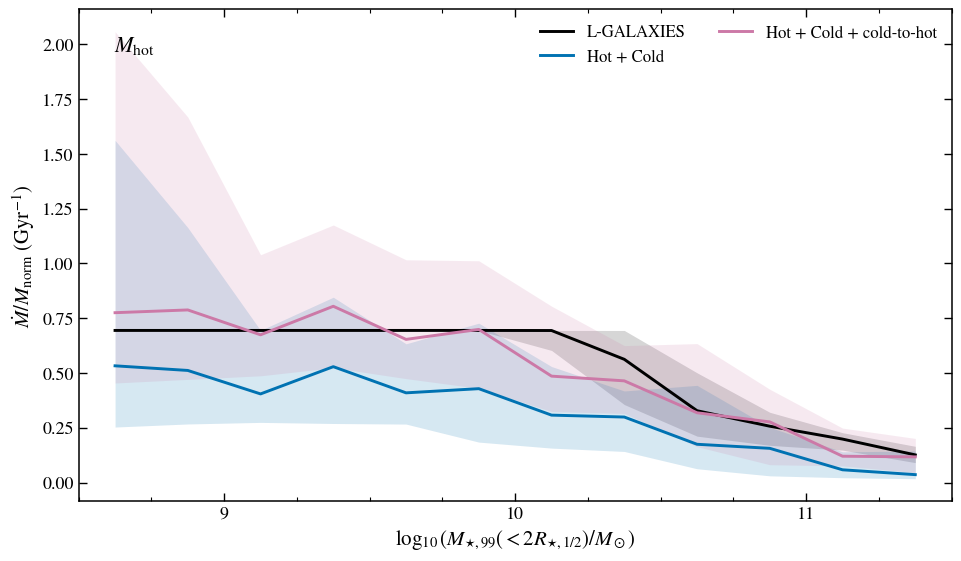

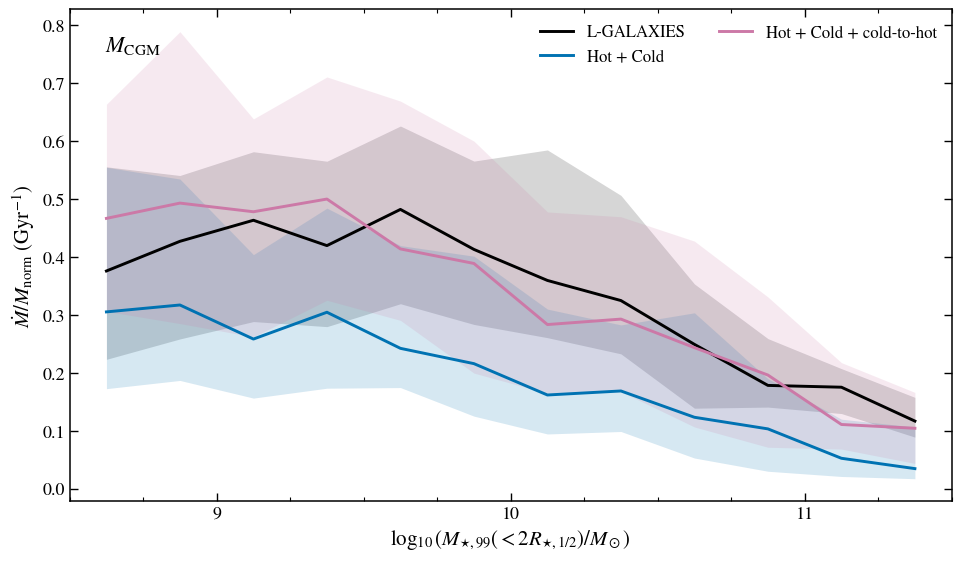

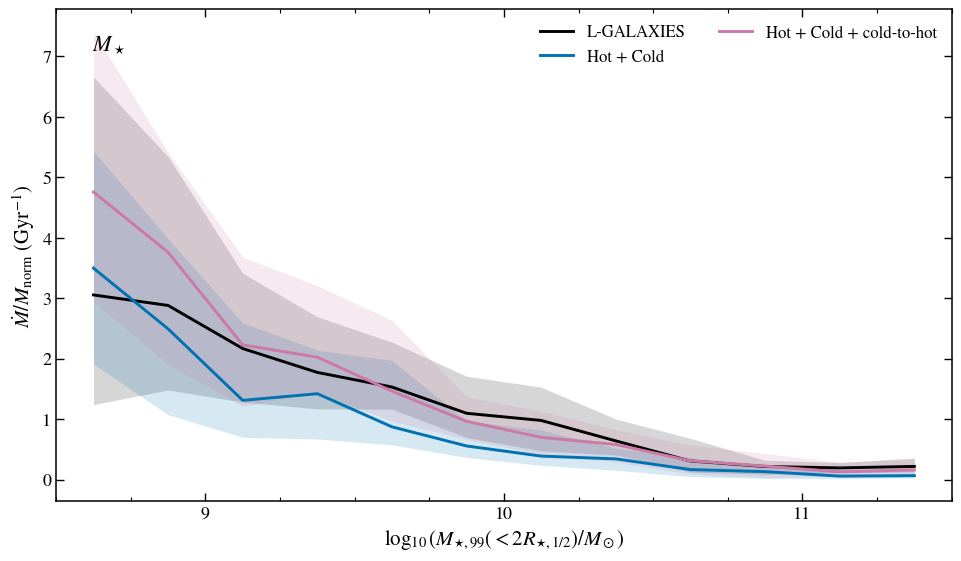

In [12]:
from src.analysis.supply_diagnostics import (
    add_cold_to_hot_supply_percentiles,
)
from src.plotting import (
    NORMALIZATION_STYLES,
    _plot_selected_mass_dependence,
)

halos = result['halo_results']
normalized = result['normalized_statistics']
normalization_labels = {
    name: label for name, label, _ in NORMALIZATION_STYLES
}
plot_series = (
    ('sam', 'L-GALAXIES', '#000000'),
    ('cooling_plus_inflow', 'Hot + Cold', '#0072B2'),
    (
        'cooling_plus_cold_to_hot',
        'Hot + Cold + cold-to-hot',
        '#CC79A7',
    ),
)

for normalization in ('m200c', 'mhot', 'mcgm', 'mstar'):
    statistics = add_cold_to_hot_supply_percentiles(
        normalized[normalization],
        halos,
        normalization,
    )
    fig = _plot_selected_mass_dependence(
        statistics,
        mode='slow',
        series=plot_series,
        annotation_label=normalization_labels[normalization],
        y_label=r'$\dot{M}/M_{\rm norm}\ ({\rm Gyr}^{-1})$',
        log_y=LOG_Y,
        save_path=(
            FIGURE_DIR
            / f'phase181_mass_dependence_normalized_{normalization}'
        ),
    )
    plt.show()


cold-to-cold rates prepared: 542 / 542


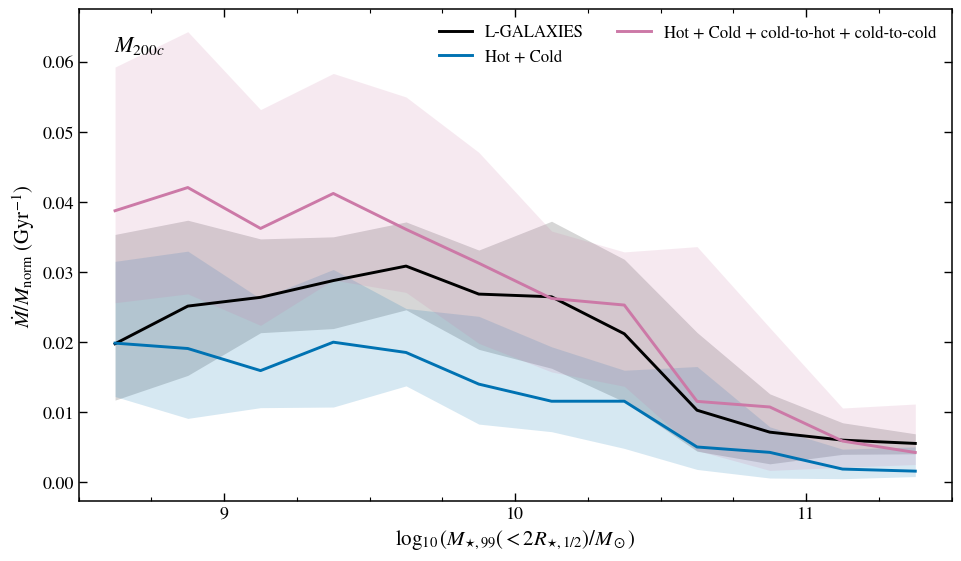

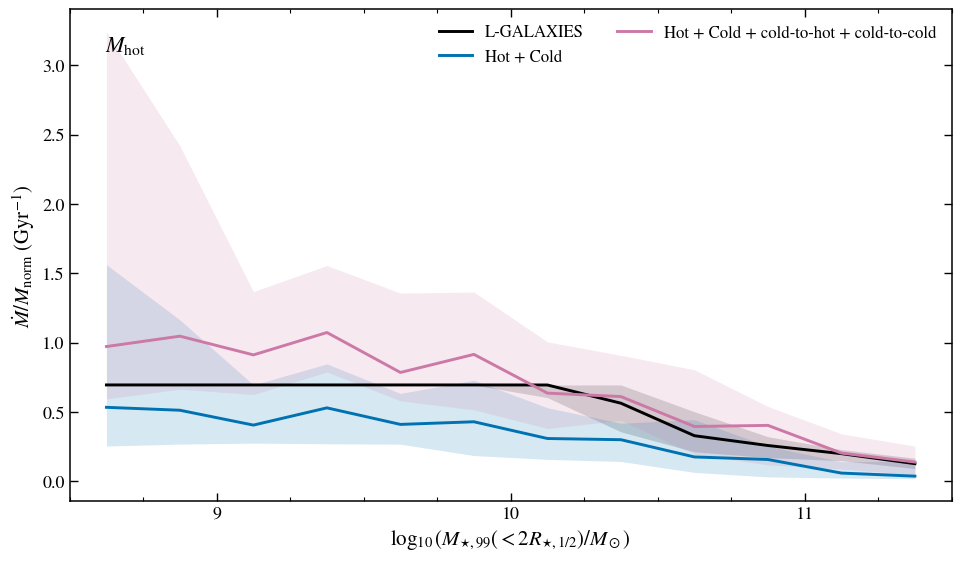

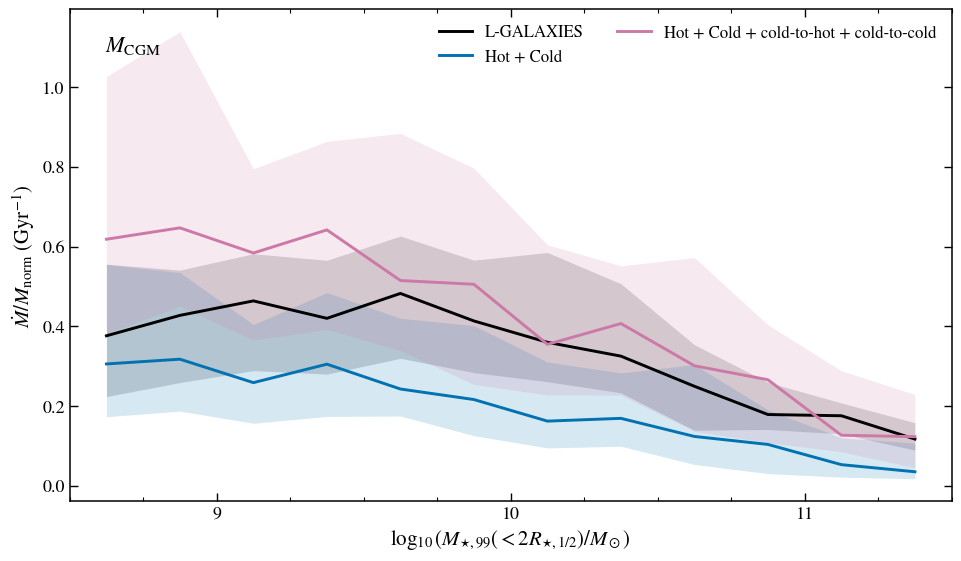

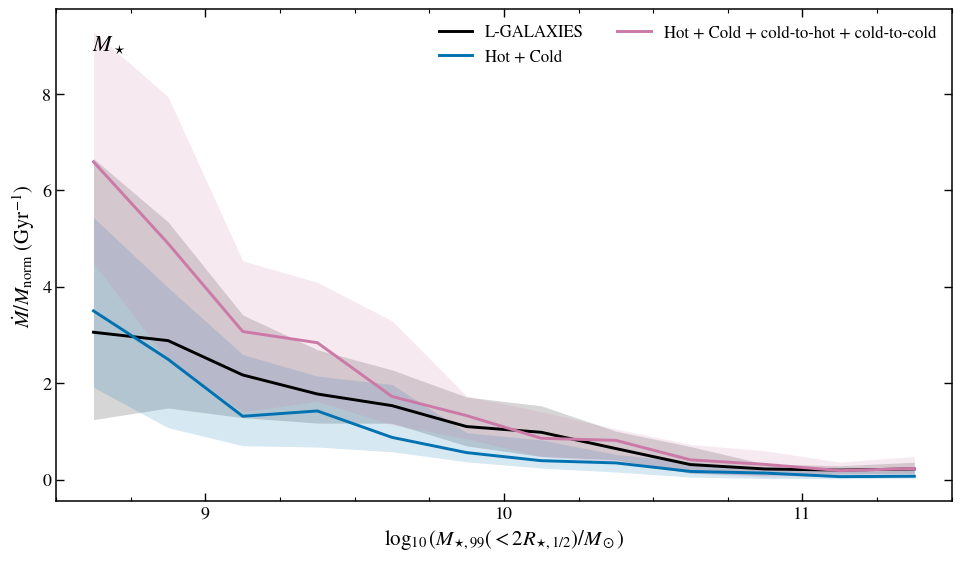

In [15]:
from src.analysis.supply_diagnostics import (
    add_cold_outflow_corrections_percentiles,
    compute_central_cold_to_outer_cold_rate,
)
from src.plotting import (
    NORMALIZATION_STYLES,
    _plot_selected_mass_dependence,
)

halos = result['halo_results']
normalized = result['normalized_statistics']
rate_central_cold_to_outer_cold_msun_per_yr, valid_cold_to_cold = (
    compute_central_cold_to_outer_cold_rate(
        halos,
        tracer_mass_msun=config.tracer_mass_msun,
    )
)
print(
    'cold-to-cold rates prepared:',
    int(np.count_nonzero(valid_cold_to_cold)),
    '/',
    len(valid_cold_to_cold),
)
normalization_labels = {
    name: label for name, label, _ in NORMALIZATION_STYLES
}
plot_series = (
    ('sam', 'L-GALAXIES', '#000000'),
    ('cooling_plus_inflow', 'Hot + Cold', '#0072B2'),
    (
        'cooling_plus_cold_to_hot_and_cold',
        'Hot + Cold + cold-to-hot + cold-to-cold',
        '#CC79A7',
    ),
)

for normalization in ('m200c', 'mhot', 'mcgm', 'mstar'):
    statistics = add_cold_outflow_corrections_percentiles(
        normalized[normalization],
        halos,
        normalization,
        tracer_mass_msun=config.tracer_mass_msun,
    )
    fig = _plot_selected_mass_dependence(
        statistics,
        mode='slow',
        series=plot_series,
        annotation_label=normalization_labels[normalization],
        y_label=r'$\dot{M}/M_{\rm norm}\ ({\rm Gyr}^{-1})$',
        log_y=LOG_Y,
        save_path=(
            FIGURE_DIR
            / f'phase181_mass_dependence_normalized_{normalization}'
        ),
    )
    plt.show()


## 6. 完备的中心冷气体来源与去向热图

左图按 tracer 计数给出 snap 99 中心冷气体的 snap 98 来源；右图给出 snap 98 中心冷气体的 snap 99 去向。每个质量 bin 内采用堆叠计数比例，`Other` 保留所有未匹配状态，因此两侧比例都应闭合为 1。

origin closure: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
fate closure: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


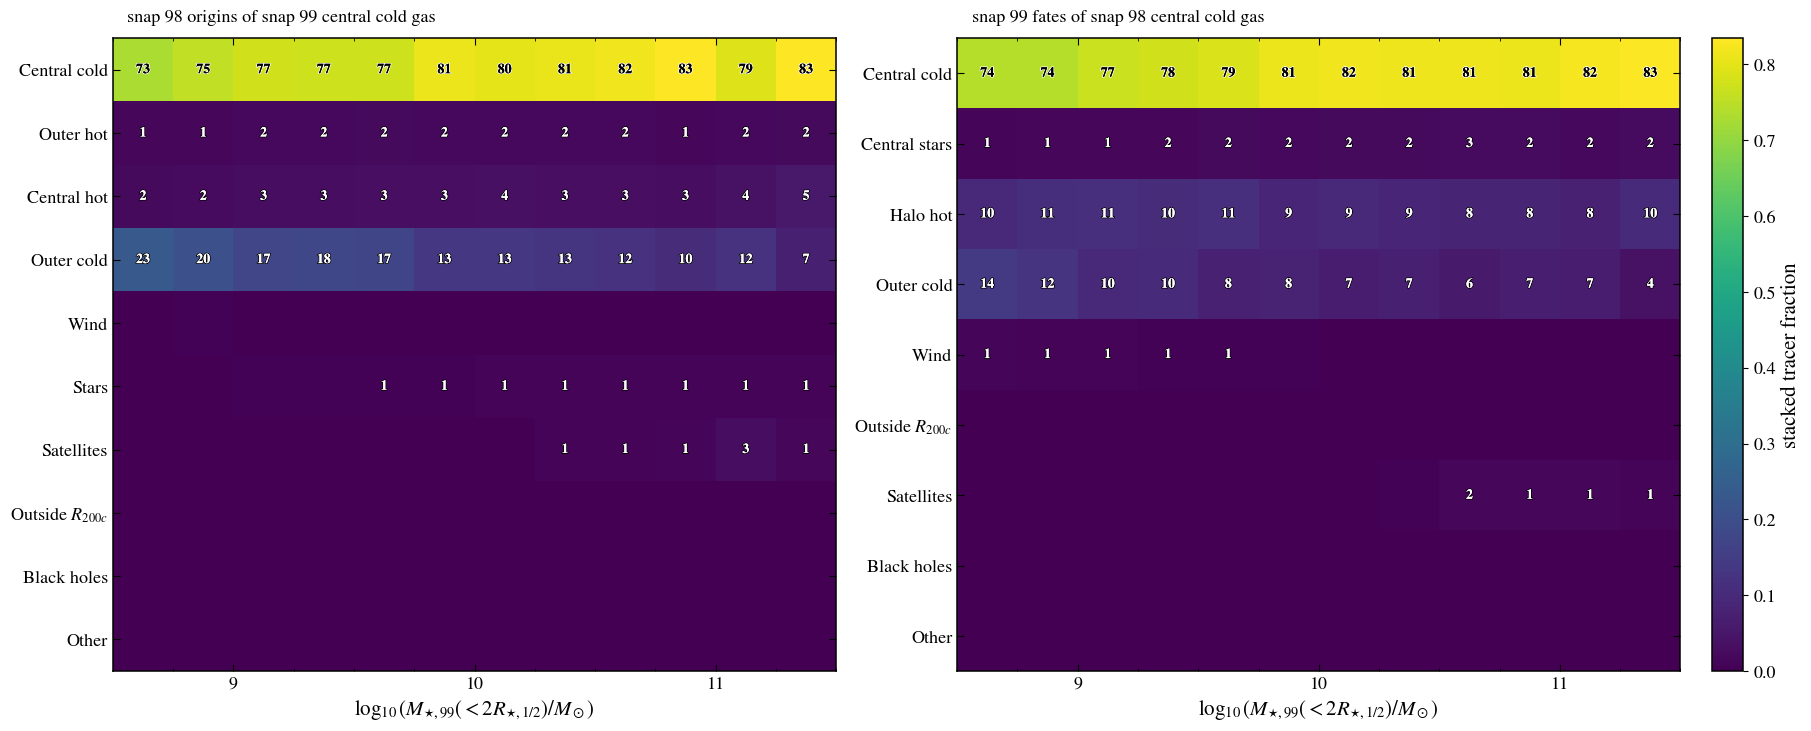

In [8]:
history = result['history_statistics']
print('origin closure:', history['origin_closure'])
print('fate closure:', history['fate_closure'])
fig = plot_tracer_history_heatmaps(
    history,
    cell_fontsize=10.0,
    cell_text_color='auto',
    cell_text_outline=True,
    save_path=FIGURE_DIR / 'phase181_tracer_central_cold_history_heatmaps',
)
plt.show()


cold-to-cold rates prepared: 542 / 542


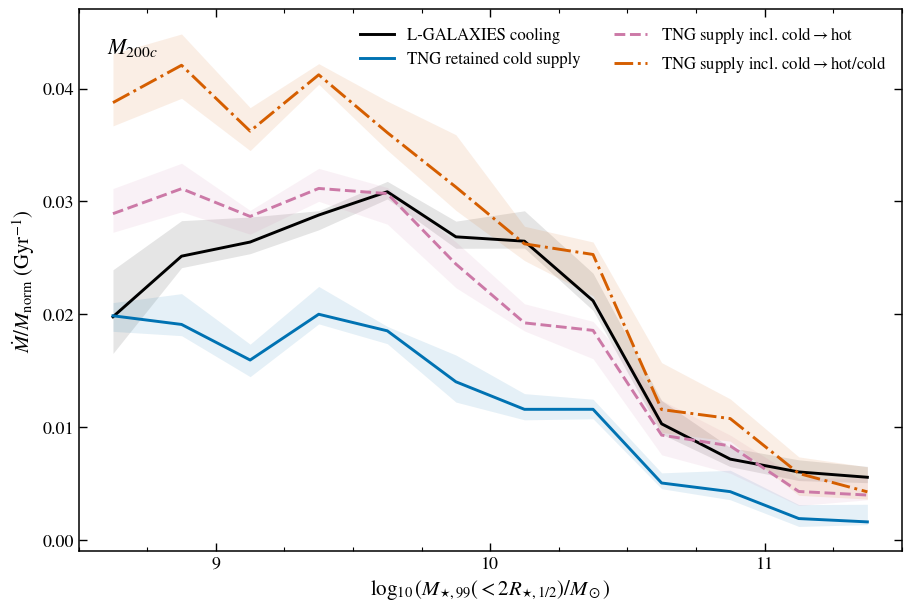

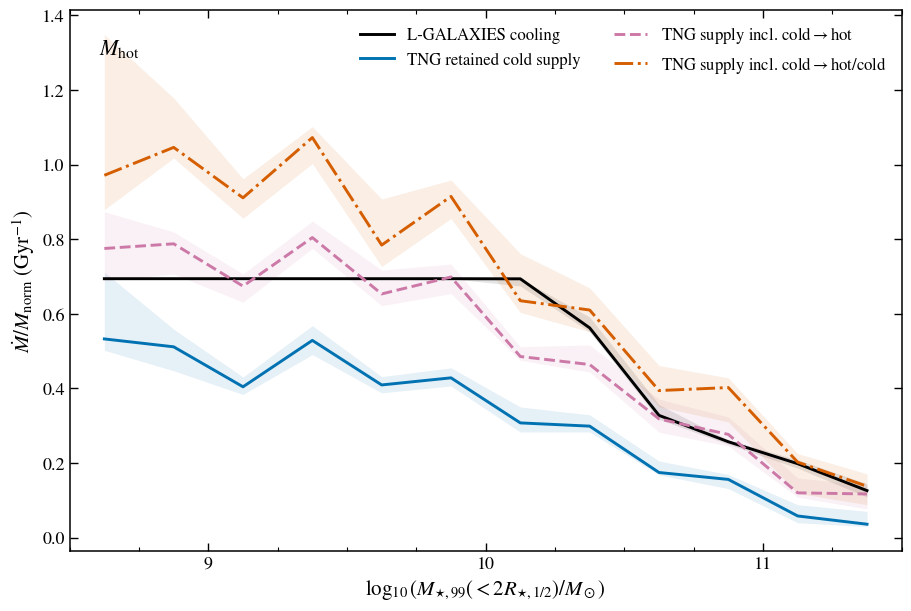

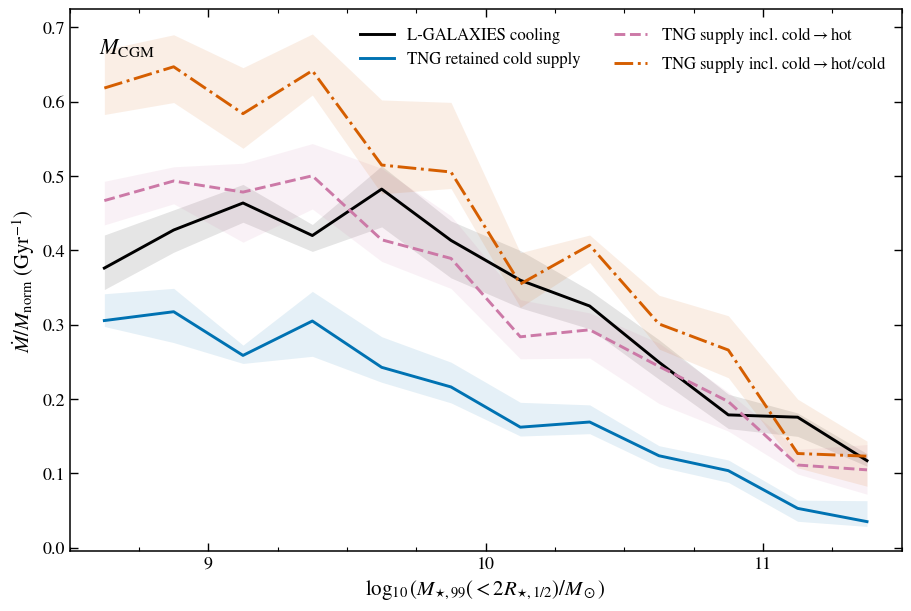

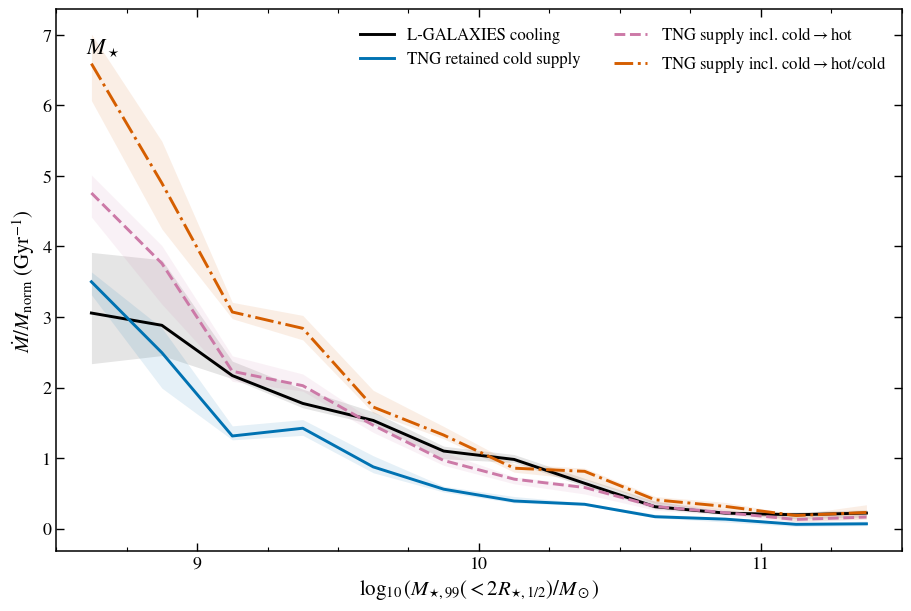

In [17]:
from src.analysis.supply_diagnostics import (
    build_supply_comparison_statistics,
    compute_central_cold_to_outer_cold_rate,
)
from src.plotting import plot_supply_comparison

halos = result['halo_results']
rate_central_cold_to_outer_cold_msun_per_yr, valid_cold_to_cold = (
    compute_central_cold_to_outer_cold_rate(
        halos,
        tracer_mass_msun=config.tracer_mass_msun,
    )
)
print(
    'cold-to-cold rates prepared:',
    int(np.count_nonzero(valid_cold_to_cold)),
    '/',
    len(valid_cold_to_cold),
)

supply_plot_statistics = {}
for normalization_index, normalization in enumerate(
    ('m200c', 'mhot', 'mcgm', 'mstar')
):
    base_statistics = result['normalized_statistics'][normalization]
    curve_summary = build_supply_comparison_statistics(
        halos,
        base_statistics,
        normalization=normalization,
        tracer_mass_msun=config.tracer_mass_msun,
        random_seed=config.random_seed,
        seed_offset=1000 + normalization_index,
        bootstrap_samples=4000,
    )
    fig = plot_supply_comparison(
        curve_summary,
        base_statistics,
        normalization=normalization,
        log_y=LOG_Y,
        save_path=(
            FIGURE_DIR
            / f'phase181_mass_dependence_normalized_{normalization}'
        ),
    )
    supply_plot_statistics[normalization] = curve_summary
    plt.show()


In [18]:
import numpy as np
import pandas as pd
from IPython.display import display

from src.analysis.result_summary import (
    summarize_history,
    summarize_tracer_channels,
)

if 'result' not in globals():
    raise RuntimeError('No result is available; run the pipeline cell first.')
if 'halo_results' not in result:
    raise KeyError("result does not contain 'halo_results'")

halos = result['halo_results']
history = result.get('history_statistics', {})
metadata = result.get('metadata', {})
snap_prev = metadata.get('snap_prev', 98)
snap_cur = metadata.get('snap_cur', 99)
print(f"Phase: {metadata.get('phase', 'unknown')}")
print(f'Snapshots: {snap_prev} -> {snap_cur}')
print(f'Number of halos: {len(next(iter(halos.values())))}')

history_tables = {}
for direction in ('origin', 'fate'):
    summary = summarize_history(
        history,
        halos,
        direction,
        snap_prev=snap_prev,
        snap_cur=snap_cur,
    )
    if summary['missing_denominator'] is not None:
        print(f"\n??? {summary['missing_denominator']}")
        history_tables[direction] = None
        continue
    table = pd.DataFrame(summary['rows'])
    history_tables[direction] = table
    print('\n' + '=' * 80)
    if direction == 'origin':
        print(f'???snap {snap_cur} ?????? snap {snap_prev} ???')
    else:
        print(f'???snap {snap_prev} ?????? snap {snap_cur} ???')
    print(f"?????{summary['denominator_key']}")
    print(f"????? tracer ??{summary['denominator_sum']}")
    display(
        table.style.format(
            {
                '????????': '{:.4f}',
                '???????': '{:.4f}',
            }
        )
    )
    closure = summary['closure']
    if closure is not None:
        print('?????')
        print(f"  ??????? = {closure['closed_halos']}")
        print(f"  ??????   = {closure['unclosed_halos']}")
        print(
            '  ?? |???? - ??| =',
            closure['max_absolute_difference'],
        )
        print(f"  ????????? = {closure['weighted_fraction']:.6f}")

origin_table = history_tables['origin']
fate_table = history_tables['fate']
channel_rows = summarize_tracer_channels(
    halos,
    snap_prev=snap_prev,
    snap_cur=snap_cur,
)
print('\n' + '=' * 80)
print('???? tracer ?????????')
if channel_rows:
    transition_table = pd.DataFrame(channel_rows)
    display(transition_table)
else:
    print('?? halo_results ??????????????')

# Report the notebook-only cold-to-cold diagnostic when it has been computed.
if 'rate_central_cold_to_outer_cold_msun_per_yr' in globals():
    values = np.asarray(
        rate_central_cold_to_outer_cold_msun_per_yr,
        dtype=float,
    )
    print('\nNotebook ?????rate_central_cold_to_outer_cold_msun_per_yr')
    print(
        '???snap 98 ????? -> snap 99 ??????'
        f'?????={np.count_nonzero(np.isfinite(values))}?'
        f'?????={np.nanmedian(values):.4g} Msun/yr'
    )


Phase: 1.8.1
Snapshots: 98 -> 99
Number of halos: 542

来源：snap 99 中心冷气体在 snap 98 的状态
分母字段：n_origin_denominator
全样本分母 tracer 数：41005614


,state,物理含义,count field,fraction field,Σ Ntracer,非零星系数,逐星系比例中位数,全样本加权比例
0,central_cold,snap 98 中心冷气体,n_origin_central_cold,fraction_origin_central_cold,33174867,536,0.7921,0.8090
1,outer_hot,snap 98 晕内外部热气体,n_origin_outer_hot,fraction_origin_outer_hot,701944,538,0.0128,0.0171
2,central_hot,snap 98 中心热气体,n_origin_central_hot,fraction_origin_central_hot,1406632,537,0.0268,0.0343
3,outer_cold,snap 98 晕内外部冷气体,n_origin_outer_cold,fraction_origin_outer_cold,4967417,538,0.1391,0.1211
4,wind,snap 98 风相粒子,n_origin_wind,fraction_origin_wind,36969,515,0.0014,0.0009
5,star,snap 98 恒星,n_origin_star,fraction_origin_star,298584,537,0.0056,0.0073
6,satellite,snap 98 卫星星系,n_origin_satellite,fraction_origin_satellite,419201,106,0.0000,0.0102
7,outside_r200c,snap 98 的 R200c 以外,n_origin_outside_r200c,fraction_origin_outside_r200c,0,0,0.0000,0.0000
8,black_hole,snap 98 黑洞,n_origin_black_hole,fraction_origin_black_hole,0,0,0.0000,0.0000
9,other,未匹配或其他状态,n_origin_other,fraction_origin_other,0,0,0.0000,0.0000


闭合检查：
  完全闭合星系数 = 542
  未闭合星系数   = 0
  最大 |Σ分类数 - 分母| = 0.0
  全样本加权闭合比例 = 1.000000

去向：snap 98 中心冷气体在 snap 99 的状态
分母字段：n_fate_denominator
全样本分母 tracer 数：40926012


,state,物理含义,count field,fraction field,Σ Ntracer,非零星系数,逐星系比例中位数,全样本加权比例
0,central_cold,snap 99 中心冷气体,n_fate_central_cold,fraction_fate_central_cold,33174867,536,0.7939,0.8106
1,central_star,snap 99 中心恒星,n_fate_central_star,fraction_fate_central_star,882031,523,0.0159,0.0216
2,halo_hot,snap 99 晕内热气体,n_fate_halo_hot,fraction_fate_halo_hot,3634047,538,0.0893,0.0888
3,outer_cold,snap 99 晕内外部冷气体,n_fate_outer_cold,fraction_fate_outer_cold,2768430,536,0.0705,0.0676
4,wind,snap 99 风相粒子,n_fate_wind,fraction_fate_wind,84300,510,0.0036,0.0021
5,outside_r200c,snap 99 的 R200c 以外,n_fate_outside_r200c,fraction_fate_outside_r200c,38,6,0.0000,0.0000
6,satellite,snap 99 卫星星系,n_fate_satellite,fraction_fate_satellite,352759,89,0.0000,0.0086
7,black_hole,snap 99 黑洞,n_fate_black_hole,fraction_fate_black_hole,947,263,0.0000,0.0000
8,other,未匹配或其他状态,n_fate_other,fraction_fate_other,28593,286,0.0000,0.0007


闭合检查：
  完全闭合星系数 = 542
  未闭合星系数   = 0
  最大 |Σ分类数 - 分母| = 0.0
  全样本加权闭合比例 = 1.000000

其他通过 tracer 交集计算的转移通道


,channel,物理含义,内存中的字段,Σ Ntracer,质量中位数 [Msun],速率中位数 [Msun/yr]
0,hot_halo_cooling,snap 98 外晕热气体 -> snap 99 中心冷气体或中心恒星,"n_hot_halo_cooling, mass_hot_halo_cooling_msun...",703545,4.638305e+07,0.339832
1,outer_cold_inflow,snap 98 外部冷气体 -> snap 99 中心冷气体或中心恒星,"n_outer_cold_inflow, mass_outer_cold_inflow_ms...",5009399,4.337132e+08,3.177658
2,cooling_plus_inflow,hot_halo_cooling + outer_cold_inflow,"n_cooling_plus_inflow, mass_cooling_plus_inflo...",5712944,4.906860e+08,3.595076
3,tng_cold_to_hot_transition,snap 98 中心冷气体 -> snap 99 晕内热气体,"n_tng_cold_to_hot_transition, mass_tng_cold_to...",3634047,3.129479e+08,2.292854
4,outer_hot_to_inner_hot,snap 98 外晕热气体 -> snap 99 中心区域热气体,"n_outer_hot_to_inner_hot, mass_outer_hot_to_in...",612750,1.554573e+07,0.113898
5,outer_cold_to_inner_hot,snap 98 外部冷气体 -> snap 99 中心区域热气体,"n_outer_cold_to_inner_hot, mass_outer_cold_to_...",640580,3.994449e+07,0.292659
6,inner_hot_delivery,outer_hot_to_inner_hot + outer_cold_to_inner_hot,"n_inner_hot_delivery, mass_inner_hot_delivery_...",1253330,6.014970e+07,0.440695
7,tng_total_inward_delivery,cooling_plus_inflow + inner_hot_delivery,"n_tng_total_inward_delivery, mass_tng_total_in...",6966274,5.702361e+08,4.177911



Notebook 临时变量：rate_central_cold_to_outer_cold_msun_per_yr
含义：snap 98 中心冷气体 -> snap 99 外部冷气体；有效星系数=542，速率中位数=1.63 Msun/yr


origin Top 4: ['central_cold', 'outer_cold', 'central_hot', 'outer_hot'] | Other combines: ['wind', 'star', 'satellite', 'outside_r200c', 'black_hole', 'other']
fate Top 4: ['central_cold', 'halo_hot', 'outer_cold', 'central_star'] | Other combines: ['wind', 'outside_r200c', 'satellite', 'black_hole', 'other']


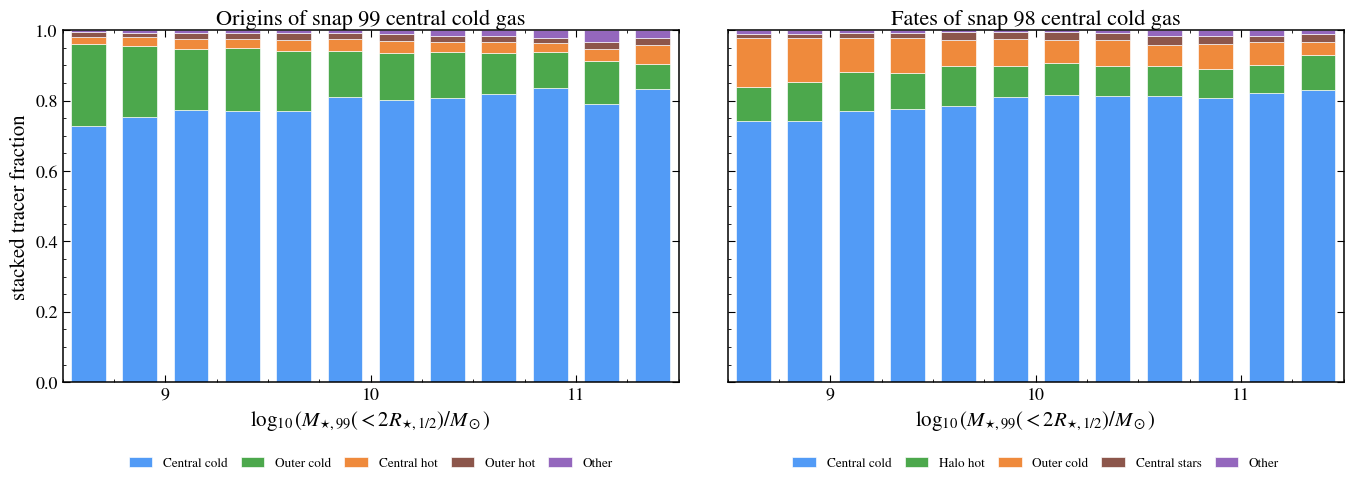

In [26]:
from src.analysis.history_diagnostics import (
    build_top4_history_statistics,
)
from src.plotting import plot_tracer_history_top4_stacked_bars

history = result['history_statistics']
halos = result['halo_results']
history_bar_statistics = build_top4_history_statistics(history, halos)

for prefix in ('origin', 'fate'):
    statistics = history_bar_statistics[prefix]
    print(
        f'{prefix} Top 4:',
        statistics['names'][:4],
        '| Other combines:',
        statistics['other_members'],
    )

fig = plot_tracer_history_top4_stacked_bars(
    history,
    history_bar_statistics,
    save_path=(
        FIGURE_DIR
        / 'phase181_tracer_central_cold_history_top4_stacked_bars'
    ),
)
plt.show()
